<a href="https://colab.research.google.com/github/nosadchiy/public/blob/main/Retailers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#(c) Nikolay Osadchiy, 2022, 2026.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install linearmodels scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.9 MB/s eta 0:00:00


In [2]:
url = 'https://www.dropbox.com/scl/fi/0cv9376y264mnqzzl08ns/retailers_cstat.csv?rlkey=4c5ze370cq4m1zjjtt50fn4fs&dl=1'
retstat = pd.read_csv(url)

# Data cleaning
retstat = retstat.dropna(subset=['year'])
retstat['q'] = retstat['year'] * 4 + (retstat['qtr'] - 1)

# Feature Engineering
retstat['it'] = retstat['cogsq'] / retstat['invtq']
retstat['gm'] = (retstat['saleq'] - retstat['cogsq']) / retstat['saleq']
retstat['ci'] = retstat['ppentq'] / (retstat['ppentq'] + retstat['invtq'])

# Filter positive values
retstat = retstat[(retstat['gm'] > 0) & (retstat['it'] > 0) & (retstat['ci'] > 0)]

# List unique tickers
print(f"Unique Tickers: {retstat['tic'].unique()[:10]}...")
display(retstat.head())

Unique Tickers: ['BBY' 'CATO' 'CBRL' 'TGT' 'DDS' 'DG' 'ASNA' 'M' 'GPS' 'GCO']...


,fid,datacqtr,gvkey,tic,sic,naics,atq,cogsq,invtq,ppentq,saleq,prccq,year,qtr,q,it,gm,ci
0,7,2000Q1,2184,BBY,5731,443142,2995.342,3504.075,1183.681,698.084,4314.615,54.625,2000.0,1.0,8000.0,2.960320,0.187859,0.370973
1,7,2000Q2,2184,BBY,5731,443142,3260.850,2326.125,1314.448,744.149,2963.718,64.000,2000.0,2.0,8001.0,1.769659,0.215133,0.361484
2,7,2000Q3,2184,BBY,5731,443142,3644.187,2483.426,1456.752,889.401,3169.171,61.750,2000.0,3.0,8002.0,1.704769,0.216380,0.379089
3,7,2000Q4,2184,BBY,5731,443142,4781.964,3000.039,2327.798,1049.801,3732.080,25.750,2000.0,4.0,8003.0,1.288788,0.196148,0.310813
4,7,2001Q1,2184,BBY,5731,443142,4839.587,4290.500,1766.934,1444.172,5461.583,40.960,2001.0,1.0,8004.0,2.428217,0.214422,0.449743


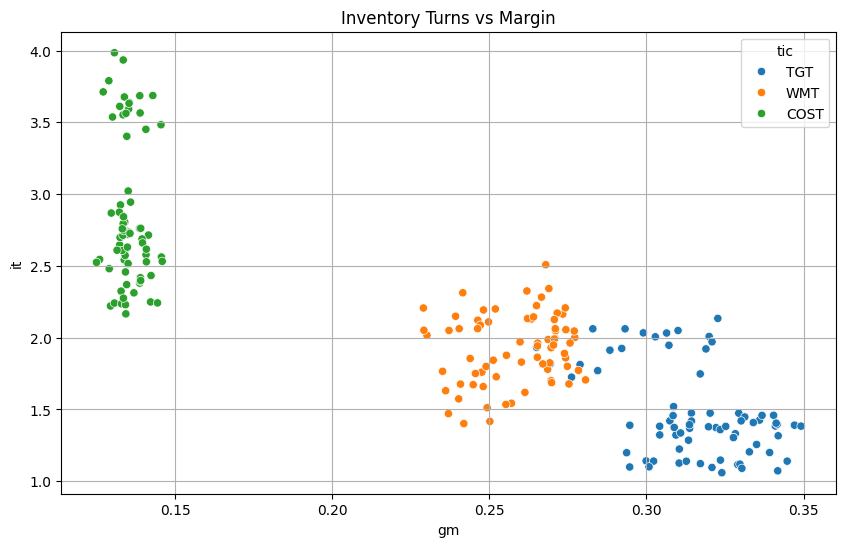

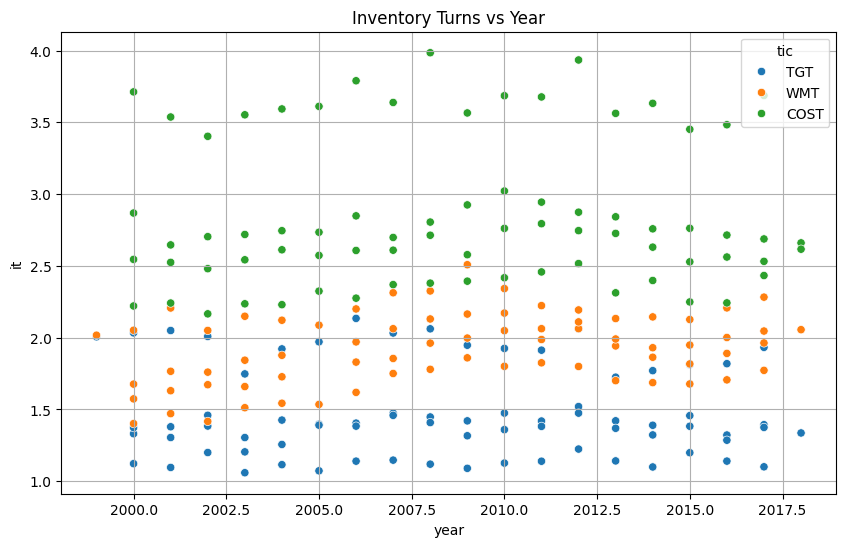

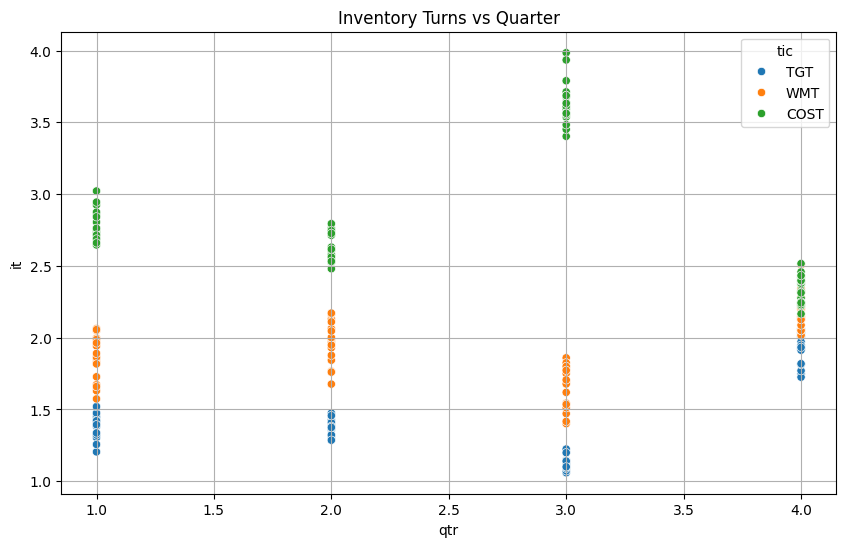

In [3]:
subset_tics = ['WMT', 'COST', 'TGT']
plot_data = retstat[retstat['tic'].isin(subset_tics)]

def plot_it(data, x_var, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=x_var, y='it', hue='tic')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_it(plot_data, 'gm', 'Inventory Turns vs Margin')
plot_it(plot_data, 'year', 'Inventory Turns vs Year')
plot_it(plot_data, 'qtr', 'Inventory Turns vs Quarter')

In [4]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Prepare logs
retstat['lit'] = np.log(retstat['it'])
retstat['lgm'] = np.log(retstat['gm'])
retstat['lci'] = np.log(retstat['ci'])

# Set multi-index for panel data (Entity and Time)
retstat = retstat.set_index(['fid', 'q']).sort_index()

# Calculate Lagged Sales (Lag 4)
retstat['saleqLag4'] = retstat.groupby(level=0)['saleq'].shift(4)
retstat['lss'] = np.log(retstat['saleq'] / retstat['saleqLag4'])

# Fixed Effects Model
# Dropping NaNs created by lag
model_data = retstat.dropna(subset=['lit', 'lgm', 'lci', 'lss'])
exog = sm.add_constant(model_data[['lgm', 'lci', 'lss']])
fixed = PanelOLS(model_data['lit'], exog, entity_effects=True)
res_fixed = fixed.fit()
print(res_fixed)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    lit   R-squared:                        0.1550
Estimator:                   PanelOLS   R-squared (Between):              0.2726
No. Observations:                3121   R-squared (Within):               0.1550
Date:                Wed, Apr 08 2026   R-squared (Overall):              0.2602
Time:                        14:31:17   Log-likelihood                   -200.80
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      187.82
Entities:                          46   P-value                           0.0000
Avg Obs:                       67.848   Distribution:                  F(3,3072)
Min Obs:                       19.000                                           
Max Obs:                       70.000   F-statistic (robust):             187.82
                            

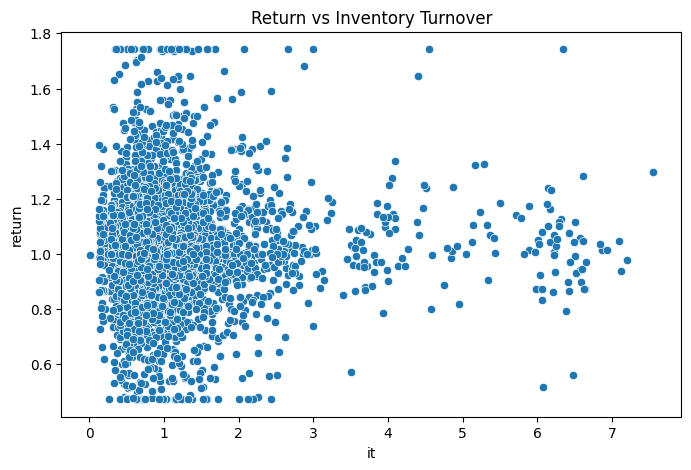

In [5]:
from scipy.stats.mstats import winsorize

# Stock returns
retstat['priceLag1'] = retstat.groupby(level=0)['prccq'].shift(1)
retstat['return'] = retstat['prccq'] / retstat['priceLag1']

# Winsorize 1% and 99%
retstat['return'] = winsorize(retstat['return'].fillna(1), limits=[0.01, 0.01])

# Quick plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=retstat.reset_index(), x='it', y='return')
plt.title('Return vs Inventory Turnover')
plt.show()